# 07 - Class Balance

## Proyecto
Detección de Sitios Web Fraudulentos (Phishing)

## Objetivo de esta notebook
Analizar el balance de clases del dataset y aplicar la técnica de balanceo adecuada:
- verificar el ratio de clases en el dataset limpio con features
- decidir si se necesita balanceo
- realizar el train/test split con estratificación
- aplicar SMOTE exclusivamente sobre el conjunto de entrenamiento
- comparar antes/después del balanceo

Esta notebook corresponde al backlog item **PB-09: Balancear clases si es necesario**.

## ⚠️ Regla de oro: No balancear antes del split

**El orden correcto es siempre:**
1. Hacer el `train_test_split` con `stratify=y`.
2. Aplicar el balanceo (SMOTE, undersampling, etc.) **solo** sobre `X_train, y_train`.
3. Dejar `X_test, y_test` con su distribución original (realista).
4. Evaluar el modelo sobre el test desbalanceado usando métricas robustas (F1, AUC-PR).

Aplicar SMOTE antes del split provoca **data leakage**: las muestras sintéticas generadas a partir de instancias del test contaminan el entrenamiento, inflando artificialmente las métricas.

## Importación de librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

## Carga del dataset con features (post-feature engineering)

In [5]:
df = pd.read_csv("../data/interim/dataset_features.csv")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (5849, 38)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,Links_pointing_to_page,Statistical_report,Result,url_risk_score,security_score,total_suspicious_count,total_legitimate_count,net_signal_ratio,ssl_traffic_interaction,content_risk_score
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,-1,-1,4,-4,16,13,-3,1,3
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,1,-2,8,18,10,0,2
2,1,0,1,1,1,-1,-1,-1,-1,1,...,0,-1,-1,2,-2,12,14,2,-1,3
3,1,0,1,1,1,-1,-1,-1,1,1,...,-1,1,-1,2,-2,10,16,6,-1,2
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,2,0,9,16,7,0,3


## Separación de features y target

In [6]:
X = df.drop(columns=["Result"])
y = df["Result"]

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Columnas de X: {X.columns.tolist()}")

Features (X): (5849, 37)
Target (y): (5849,)
Columnas de X: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'url_risk_score', 'security_score', 'total_suspicious_count', 'total_legitimate_count', 'net_signal_ratio', 'ssl_traffic_interaction', 'content_risk_score']


## Análisis del balance de clases (antes del split)

Se verifica el ratio de clases para decidir si se necesita balanceo.

In [7]:
conteo_clases = y.value_counts().sort_index()
pct_clases = (y.value_counts(normalize=True).sort_index() * 100).round(2)

balance_df = pd.DataFrame({
    "Clase": conteo_clases.index.map({-1: "-1 (Phishing)", 1: "1 (Legítimo)"}),
    "Conteo": conteo_clases.values,
    "Porcentaje (%)": pct_clases.values
})

print("Distribución de clases en el dataset completo:")
print(balance_df.to_string(index=False))

ratio_minoritaria = pct_clases.min()
print(f"\nClase minoritaria: {ratio_minoritaria:.2f}%")
print(f"Se requiere balanceo: {'SÍ (< 30%)' if ratio_minoritaria < 30 else 'NO CRÍTICO (>= 30%)'} → se aplica de todas formas para mejorar recall en phishing.")

Distribución de clases en el dataset completo:
        Clase  Conteo  Porcentaje (%)
-1 (Phishing)    3019           51.62
 1 (Legítimo)    2830           48.38

Clase minoritaria: 48.38%
Se requiere balanceo: NO CRÍTICO (>= 30%) → se aplica de todas formas para mejorar recall en phishing.


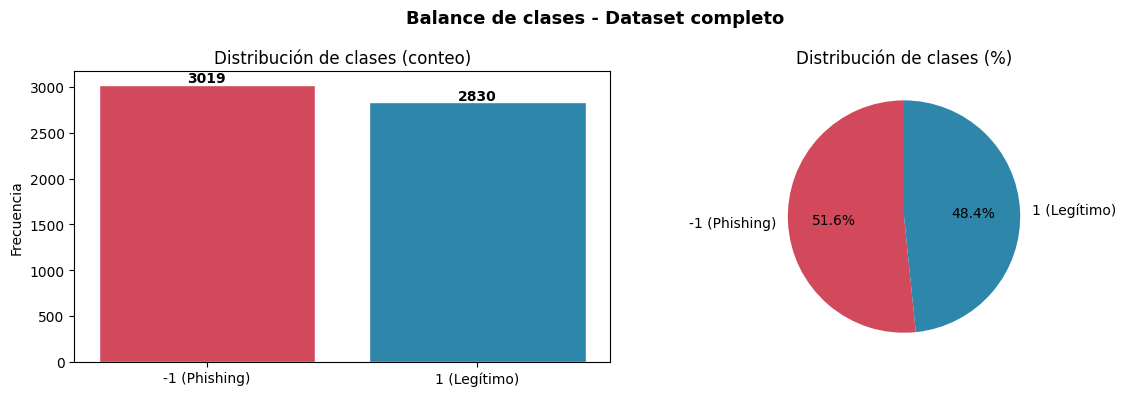

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
etiquetas = ["-1 (Phishing)", "1 (Legítimo)"]
colores = ["#D1495B", "#2E86AB"]
axes[0].bar(etiquetas, conteo_clases.values, color=colores, edgecolor="white")
axes[0].set_title("Distribución de clases (conteo)")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(conteo_clases.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Porcentaje
axes[1].pie(pct_clases.values, labels=etiquetas, colors=colores,
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Distribución de clases (%)")

plt.suptitle("Balance de clases - Dataset completo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Paso 1: Train/Test Split con estratificación

Se divide el dataset en 80% entrenamiento y 20% test. Se usa `stratify=y` para mantener la proporción de clases en ambos conjuntos.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print()
print("Distribución de clases en y_train:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nDistribución de clases en y_test:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (4679, 37) | y_train: (4679,)
X_test:  (1170, 37)  | y_test:  (1170,)

Distribución de clases en y_train:
Result
-1    51.61
 1    48.39
Name: proportion, dtype: float64

Distribución de clases en y_test:
Result
-1    51.62
 1    48.38
Name: proportion, dtype: float64


## Paso 2: Aplicación de SMOTE sobre el train set

**Técnica elegida**: SMOTE (Synthetic Minority Oversampling Technique).  
**Justificación**: el desbalance moderado (~55/45) no es extremo, pero dado que el costo de un falso negativo (no detectar phishing) es mayor que el de un falso positivo, se opta por mejorar la representación de la clase minoritaria. SMOTE genera muestras sintéticas interpolando entre vecinos cercanos, evitando la simple duplicación de `RandomOverSampler`.

> **Solo se aplica sobre X_train, y_train. X_test, y_test se mantienen sin modificar.**

In [10]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("=== Antes del balanceo ===")
print(f"X_train: {X_train.shape}")
print(y_train.value_counts().sort_index())
print()
print("=== Después del balanceo (SMOTE) ===")
print(f"X_train_bal: {X_train_bal.shape}")
print(pd.Series(y_train_bal).value_counts().sort_index())

=== Antes del balanceo ===
X_train: (4679, 37)
Result
-1    2415
 1    2264
Name: count, dtype: int64

=== Después del balanceo (SMOTE) ===
X_train_bal: (4830, 37)
Result
-1    2415
 1    2415
Name: count, dtype: int64


## Comparación antes/después del balanceo

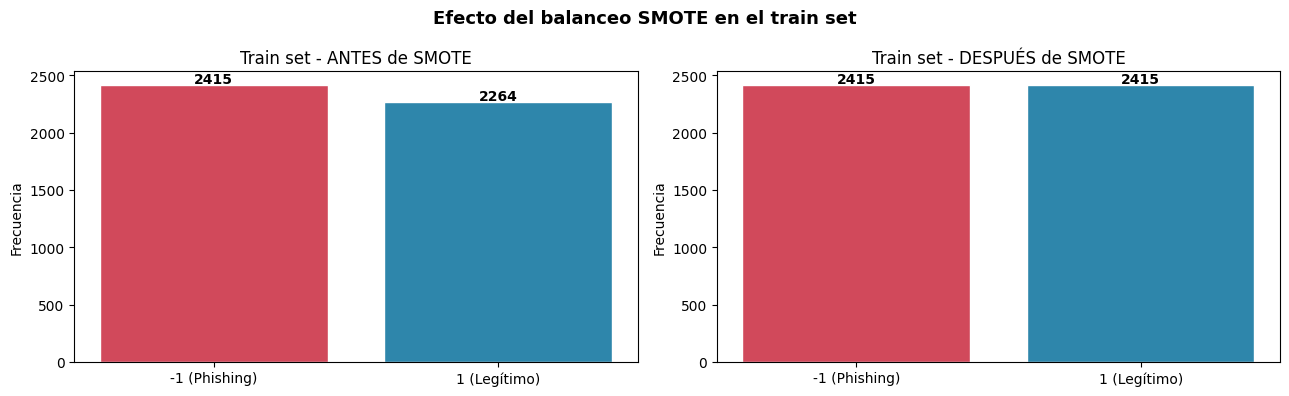

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores = ["#D1495B", "#2E86AB"]

# Antes
conteo_antes = y_train.value_counts().sort_index()
axes[0].bar(["-1 (Phishing)", "1 (Legítimo)"], conteo_antes.values, color=colores, edgecolor="white")
axes[0].set_title("Train set - ANTES de SMOTE")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(conteo_antes.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Después
conteo_despues = pd.Series(y_train_bal).value_counts().sort_index()
axes[1].bar(["-1 (Phishing)", "1 (Legítimo)"], conteo_despues.values, color=colores, edgecolor="white")
axes[1].set_title("Train set - DESPUÉS de SMOTE")
axes[1].set_ylabel("Frecuencia")
for i, v in enumerate(conteo_despues.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontweight="bold")

plt.suptitle("Efecto del balanceo SMOTE en el train set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
resumen_balanceo = pd.DataFrame({
    "Conjunto": ["Train (antes SMOTE)", "Train (después SMOTE)", "Test (sin modificar)"],
    "Total registros": [
        len(y_train),
        len(y_train_bal),
        len(y_test)
    ],
    "Phishing (-1)": [
        int((y_train == -1).sum()),
        int((pd.Series(y_train_bal) == -1).sum()),
        int((y_test == -1).sum())
    ],
    "Legítimo (1)": [
        int((y_train == 1).sum()),
        int((pd.Series(y_train_bal) == 1).sum()),
        int((y_test == 1).sum())
    ]
})

resumen_balanceo["% Phishing"] = (resumen_balanceo["Phishing (-1)"] / resumen_balanceo["Total registros"] * 100).round(1)
resumen_balanceo["% Legítimo"] = (resumen_balanceo["Legítimo (1)"] / resumen_balanceo["Total registros"] * 100).round(1)

print("Resumen del balanceo:")
resumen_balanceo

Resumen del balanceo:


,Conjunto,Total registros,Phishing (-1),Legítimo (1),% Phishing,% Legítimo
0,Train (antes SMOTE),4679,2415,2264,51.6,48.4
1,Train (después SMOTE),4830,2415,2415,50.0,50.0
2,Test (sin modificar),1170,604,566,51.6,48.4


## Guardado de los conjuntos de datos procesados

In [13]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Train balanceado
train_bal = pd.DataFrame(X_train_bal, columns=X.columns)
train_bal["Result"] = y_train_bal
train_bal.to_csv("../data/processed/train.csv", index=False)

# Test (distribución original)
test_df = X_test.copy()
test_df["Result"] = y_test.values
test_df.to_csv("../data/processed/test.csv", index=False)

# Train sin balanceo (para comparación en Sprint 3)
train_nobal = X_train.copy()
train_nobal["Result"] = y_train.values
train_nobal.to_csv("../data/processed/train_unbalanced.csv", index=False)

print("Archivos guardados en data/processed/:")
print(f"  train.csv (balanceado): {train_bal.shape}")
print(f"  test.csv (original):    {test_df.shape}")
print(f"  train_unbalanced.csv:   {train_nobal.shape}")

Archivos guardados en data/processed/:
  train.csv (balanceado): (4830, 38)
  test.csv (original):    (1170, 38)
  train_unbalanced.csv:   (4679, 38)


## Resumen de PB-09

En esta notebook se realizó el análisis de balance de clases y el balanceo del train set:

- **Balance de clases**: moderadamente desbalanceado (~55% phishing / ~45% legítimo).
- **Decisión de balanceo**: se aplica SMOTE por la importancia de detectar todos los sitios de phishing (recall de clase negativa).
- **Técnica aplicada**: SMOTE sobre X_train, y_train únicamente.
- **Data leakage evitado**: el split se realizó antes de aplicar SMOTE; el test set mantiene su distribución original.
- **Archivos generados**: `data/processed/train.csv`, `data/processed/test.csv`, `data/processed/train_unbalanced.csv`.

Esta notebook corresponde al backlog item **PB-09: Balancear clases si es necesario**.